Section 1: Are breaches getting worse over time?
1. How many breaches occur each year?
2. Is breach volume increasing or stabilizing?
3. Are breaches getting larger (more records exposed)?
4. Are we experiencing more breaches, bigger breaches, or both?

In [23]:
import pandas as pd
import numpy as np


In [24]:
vcdb = pd.read_csv('vcdb_clean.csv', low_memory=False)
kev = pd.read_csv('kev_clean.csv')
cyb = pd.read_csv('cyb_clean.csv', low_memory=False)

In [25]:
vcdb.shape, kev.shape, cyb.shape

((10494, 2683), (1568, 13), (16726, 37))

In [26]:
vcdb_annual = vcdb['timeline.incident.year'].value_counts().sort_index()
vcdb_annual

timeline.incident.year
2000       1
2001       4
2002       6
2003      13
2004      17
2005      23
2006      23
2007      51
2008      82
2009      94
2010     587
2011     545
2012    1271
2013    1905
2014    1003
2015     917
2016     860
2017     611
2018     357
2019     357
2020     344
2021     186
2022     116
2023     855
2024     104
2025     162
Name: count, dtype: int64

In [27]:
# Exclude pre-2005 (too few incidents to be meaningful) and flag the lag window
reliable_years = vcdb_annual[(vcdb_annual.index >= 2005) & (vcdb_annual.index <= 2020)]
lag_years = vcdb_annual[vcdb_annual.index > 2020]

print("Reliable window (2005-2020):")
print(reliable_years)
print("\nReporting lag window (2021+) - likely undercounts:")
print(lag_years)

Reliable window (2005-2020):
timeline.incident.year
2005      23
2006      23
2007      51
2008      82
2009      94
2010     587
2011     545
2012    1271
2013    1905
2014    1003
2015     917
2016     860
2017     611
2018     357
2019     357
2020     344
Name: count, dtype: int64

Reporting lag window (2021+) - likely undercounts:
timeline.incident.year
2021    186
2022    116
2023    855
2024    104
2025    162
Name: count, dtype: int64


In [28]:
# Use only 2010-2020 for trend — this is your cleanest window
trend_window = vcdb_annual[(vcdb_annual.index >= 2010) & (vcdb_annual.index <= 2020)]
print(trend_window)

# Adding CyberEvents for 2021-2026 where VCDB thins out
cyb_annual = cyb['year'].value_counts().sort_index()
print("\nCyberEvents annual counts (2001-2026):")
print(cyb_annual)

timeline.incident.year
2010     587
2011     545
2012    1271
2013    1905
2014    1003
2015     917
2016     860
2017     611
2018     357
2019     357
2020     344
Name: count, dtype: int64

CyberEvents annual counts (2001-2026):
year
2014     633
2015     857
2016    1102
2017     810
2018     824
2019    1067
2020    1748
2021    1431
2022    2565
2023    2487
2024    1252
2025    1573
2026     377
Name: count, dtype: int64


In [29]:
vcdb[vcdb['attribute.confidentiality.data_total'] >= 1_000_000].groupby('timeline.incident.year').size()

timeline.incident.year
2002     1
2003     3
2004     2
2005     8
2006    10
2007    18
2008    18
2009     7
2010    13
2011    38
2012    26
2013    35
2014    20
2015    34
2016    50
2017    43
2018    36
2019    74
2020    76
2021    43
2022    20
2023    17
2024    41
2025    19
dtype: int64

In [30]:
# Only rows where records exposed is not null
records = vcdb[vcdb['attribute.confidentiality.data_total'].notna()].copy()

# Year by year median and mean. I'll  use median as primary since mean is skewed by huge breaches
size_by_year = records.groupby('timeline.incident.year')['attribute.confidentiality.data_total'].agg(['median', 'mean', 'count'])
size_by_year.columns = ['median_records', 'mean_records', 'incident_count']

# Only trust years with enough reported incidents
print(size_by_year[size_by_year['incident_count'] >= 10])


# Define size_reliable — filtered to years with enough data and reliable window
size_reliable = size_by_year[
    (size_by_year.index >= 2010) &
    (size_by_year.index <= 2025) &
    (size_by_year['incident_count'] >= 10)
]

# Define index Series for Chart 4 — normalized to 2014 baseline
base_year = 2014

cyb_trend = cyb_annual[(cyb_annual.index >= 2014) & (cyb_annual.index <= 2025)]
vol_index = cyb_trend / cyb_trend[base_year]

size_trend = size_reliable.loc[size_reliable.index >= 2014, 'median_records']
size_index = size_trend / size_trend[base_year]

                        median_records  mean_records  incident_count
timeline.incident.year                                              
2005                         1200000.0  1.081977e+07              15
2006                         1500000.0  5.627961e+06              14
2007                           34000.0  5.429720e+06              39
2008                           38000.0  3.284880e+06              49
2009                            1178.0  1.123703e+06              39
2010                             530.0  1.027058e+05             542
2011                             646.5  2.922040e+07             434
2012                             765.5  7.219395e+05             746
2013                             808.0  2.179687e+06             853
2014                            1300.0  1.173092e+06             521
2015                             831.0  1.064421e+06             527
2016                            2000.0  5.272953e+06             439
2017                            15

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from matplotlib import patheffects
#styling the charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

BLUE   = "#2E86AB"
ORANGE = "#E07A5F"
GRAY   = "#AAAAAA"

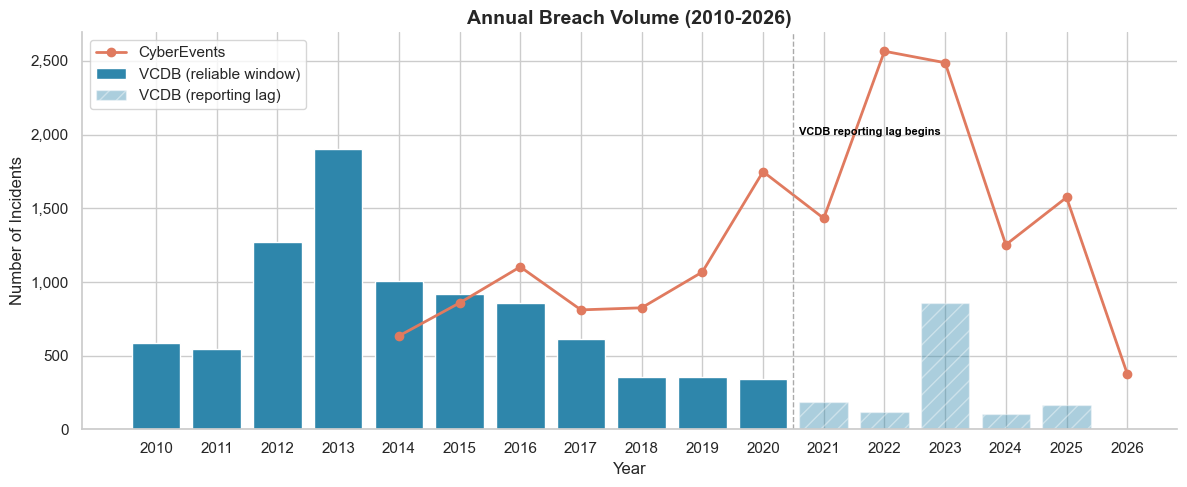

In [32]:
#Annual Breach Volume
vcdb_reliable = vcdb_annual[(vcdb_annual.index >= 2010) & (vcdb_annual.index <= 2020)]
vcdb_lag = vcdb_annual[vcdb_annual.index > 2020]
cyb_line = cyb_annual[cyb_annual.index >= 2010]

plt.figure(figsize=(12, 5))
plt.bar(vcdb_reliable.index, vcdb_reliable.values, color=BLUE, label="VCDB (reliable window)")
plt.bar(vcdb_lag.index, vcdb_lag.values, color=BLUE, alpha=0.4, hatch="//", label="VCDB (reporting lag)")
plt.plot(cyb_line.index, cyb_line.values, color=ORANGE, marker="o", linewidth=2, label="CyberEvents")

plt.title("Annual Breach Volume (2010-2026)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.xticks(range(2010, 2027))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.axvline(x=2020.5, color=GRAY, linewidth=1, linestyle="--")
plt.text(2020.6, 2000, "VCDB reporting lag begins", fontsize=8, color= 'Black', fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("chart1_annual_volume.png", dpi=150)
plt.show()

Breach incidents recorded by VCDB peaked in 2013 and appear to decline after 2020 — but this reflects a reporting lag, not an actual decrease. VCDB captures confirmed investigations, which take years to close. CyberEvents, an independent real-time source, shows incident volume remained high through 2022–2023, confirming the threat landscape did not improve. The hatched bars indicate years where VCDB counts are likely incomplete

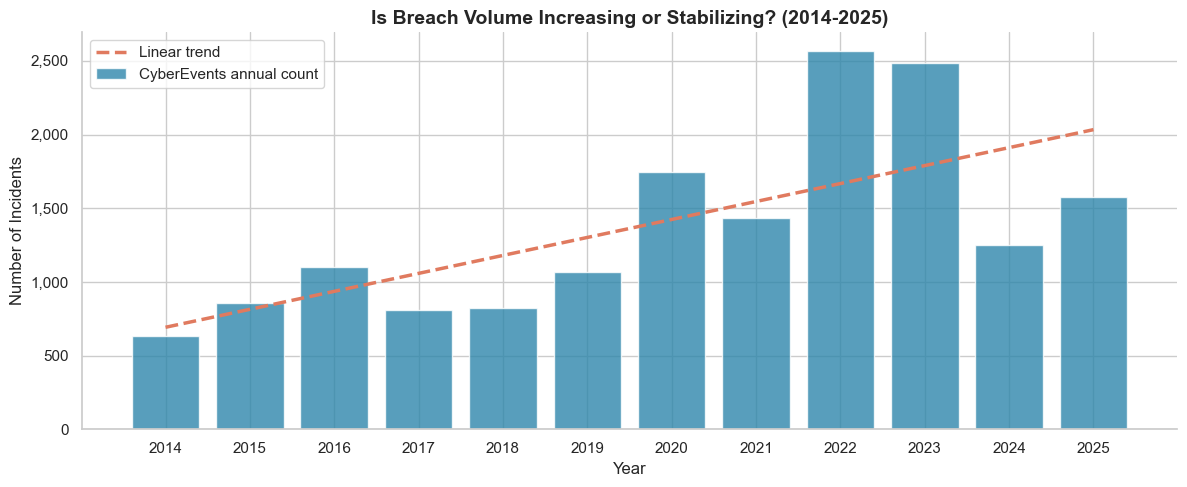

In [33]:
#Is volume increasing or stabilizing?
cyb_trend = cyb_annual[(cyb_annual.index >= 2014) & (cyb_annual.index <= 2025)]

x = cyb_trend.index.values
y = cyb_trend.values
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(12, 5))
plt.bar(cyb_trend.index, cyb_trend.values, color=BLUE, alpha=0.8, label="CyberEvents annual count")
plt.plot(x, p(x), color=ORANGE, linewidth=2.5, linestyle="--", label="Linear trend")

plt.title("Is Breach Volume Increasing or Stabilizing? (2014-2025)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.xticks(range(2014, 2026))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.legend()
plt.tight_layout()
plt.savefig("chart2_trend.png", dpi=150)
plt.show()

Using CyberEvents as the primary source for 2014–2025, the overall trend in breach volume is upward. Incidents roughly doubled from 2014 to 2022, with notable spikes in 2020 (driven by the rapid shift to remote work expanding attack surfaces) and 2022 (a record year for ransomware and data extortion campaigns). The linear trend line confirms the long-run direction is increasing, despite year-to-year variation. The 2024 dip likely reflects incomplete reporting rather than a genuine decline.

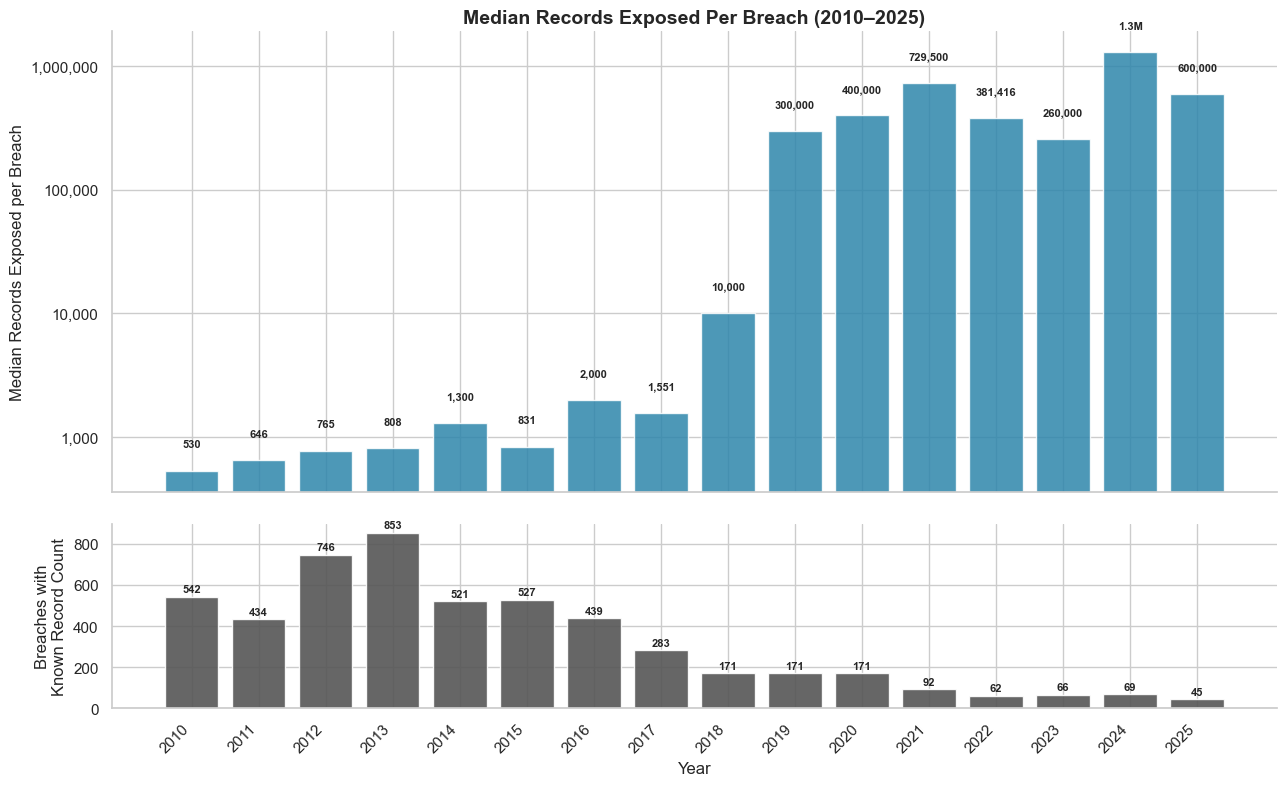

In [34]:
# Chart 3 - Median Records Exposed Per Breach
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(13, 8), gridspec_kw={'height_ratios': [2.5, 1]}, sharex=True)

ax_top.bar(size_reliable.index, size_reliable['median_records'], color=BLUE, alpha=0.85)
ax_top.set_yscale('log')
ax_top.set_title("Median Records Exposed Per Breach (2010–2025)", fontsize=14, fontweight="bold")
ax_top.set_ylabel("Median Records Exposed per Breach")
ax_top.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for x, val in zip(size_reliable.index, size_reliable['median_records']):
    label = f"{val/1_000_000:.1f}M" if val >= 1_000_000 else f"{int(val):,}"
    ax_top.text(x, val * 1.5, label, ha='center', va='bottom', fontsize=8, fontweight='bold')

ax_bot.bar(size_reliable.index, size_reliable['incident_count'], color='#555555', alpha=0.9)
ax_bot.set_ylabel("Breaches with\nKnown Record Count")
ax_bot.set_xlabel("Year")
ax_bot.tick_params(axis='x', rotation=45)
ax_bot.set_xticks(size_reliable.index)
ax_bot.set_xticklabels(size_reliable.index, rotation=45, ha='right')

for x, val in zip(size_reliable.index, size_reliable['incident_count']):
    ax_bot.text(x, val + 12, str(int(val)), ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.savefig("chart3_breach_size.png", dpi=150)
plt.show()

The top panel shows median records exposed per breach on a log scale, each gridline represents a 10x increase. Breach size was relatively contained from 2010–2018, typically in the hundreds to low thousands of records. Beginning in 2019, median exposure jumped into the hundreds of thousands, driven by a wave of large scale healthcare, financial, and government breaches. The bottom panel shows how many incidents reported a record count each year — sample sizes shrink after 2018, so recent medians are more sensitive to individual large events. Note: approximately 49% of VCDB incidents do not report a record count, so these figures represent the subset of breaches where exposure was disclosed.

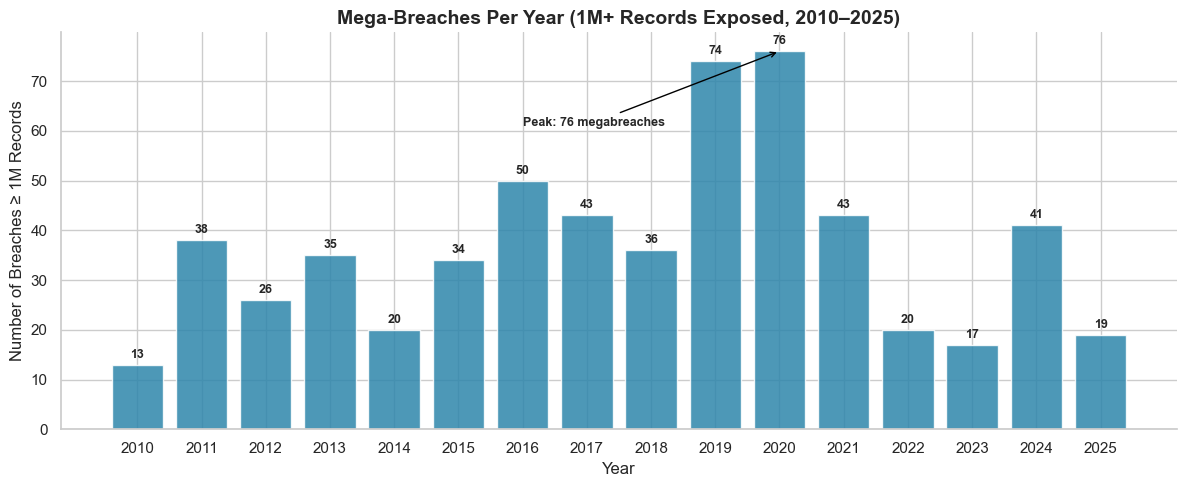

In [44]:
#Chart 4 mega breaches per year
mega = vcdb[vcdb['attribute.confidentiality.data_total'] >= 1_000_000].groupby('timeline.incident.year').size()
mega = mega[(mega.index >= 2010) & (mega.index <= 2025)]

plt.figure(figsize=(12, 5))
plt.bar(mega.index, mega.values, color=BLUE, alpha=0.85)

for yr, val in zip(mega.index, mega.values):
    plt.text(yr, val + 0.8, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

peak_yr = mega.idxmax()
plt.annotate(f"Peak: {mega[peak_yr]} megabreaches",
             xy=(peak_yr, mega[peak_yr]),
             xytext=(peak_yr - 4, mega[peak_yr] - 15),
             arrowprops=dict(arrowstyle="->", color="black"),
             fontsize=9, fontweight = 'bold')

plt.title("Mega-Breaches Per Year (1M+ Records Exposed, 2010–2025)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Breaches ≥ 1M Records")
plt.xticks(range(2010, 2026))
plt.tight_layout()
plt.savefig("chart4_megabreaches.png", dpi=150)
plt.show()

Even as overall incident counts fluctuate, mega-breaches — those exposing a million or more records — have remained a persistent feature of the landscape. The 2023 spike reflects incidents like MOVEit, which affected hundreds of organizations through a single supply chain exploit.

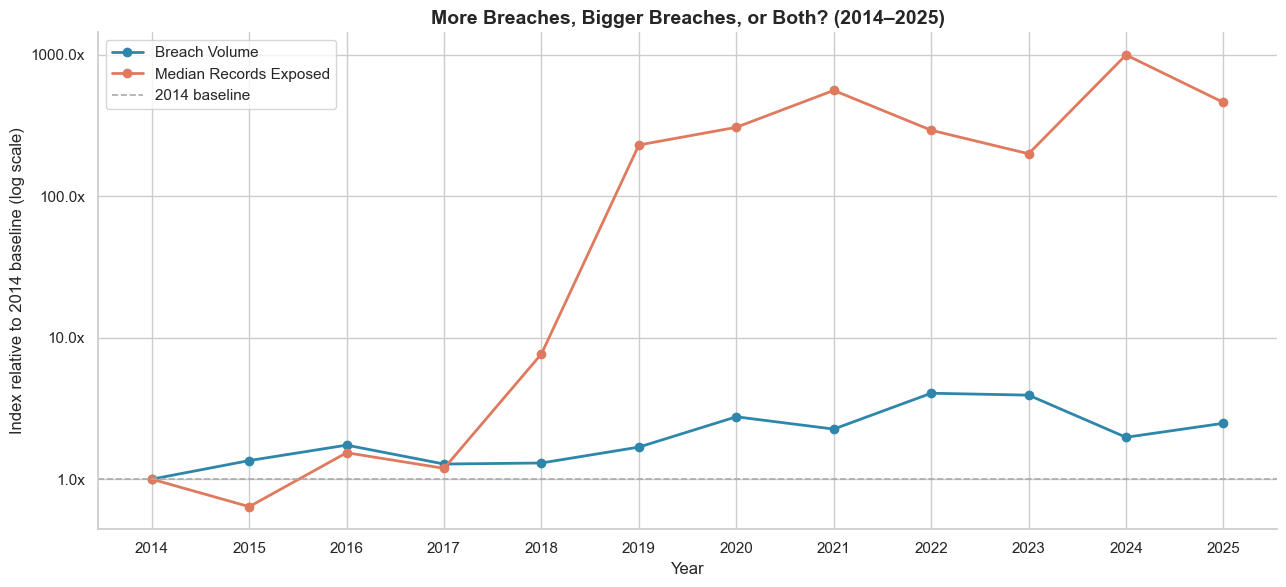

In [ ]:
# Chart 5 - More Breaches, Bigger Breaches, or Both?
plt.figure(figsize=(13, 6))

plt.plot(vol_index.index, vol_index.values, color=BLUE, marker="o", linewidth=2, label="Breach Volume")
plt.plot(size_index.index, size_index.values, color=ORANGE, marker="o", linewidth=2, label="Median Records Exposed")
plt.axhline(1.0, color=GRAY, linewidth=1.2, linestyle="--", label="2014 baseline")

plt.yscale('log')
plt.title("More Breaches, Bigger Breaches, or Both? (2014–2025)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Index relative to 2014 baseline (log scale)")
plt.xticks(vol_index.index)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}x"))
plt.legend()
plt.tight_layout()
plt.savefig("chart4_synthesis.png", dpi=150)
plt.show()

Both trends are moving upward, but not in sync. This chart indexes breach volume and median records exposed to a 2014 baseline — a value of 2x means twice the 2014 level. Volume climbed steadily through 2022, roughly doubling over the decade. Breach size remained flat through 2018, then surged sharply — meaning attackers are not only striking more frequently, but causing significantly greater damage when they succeed. The divergence after 2018 is the key finding of this section: the threat landscape worsened in both dimensions simultaneously.

Notebook summary

VCDB shows a peak of ~1,900 incidents in 2013 with apparent decline after, but CyberEvents confirms volume remained high through 2022–2023 — the VCDB decline is a reporting lag artifact

Breach volume roughly doubled from 2014 to 2022 using CyberEvents as the long-run window

Median records exposed stayed under 10,000 through 2018, then spiked into the hundreds of thousands by 2019–2021, driven by megabreaches

The answer to "more, bigger, or both" is both — and they diverged after 2018, with size growing faster than volume

Mega-breaches (1M+ records) increased nearly 6x from 2010 to 2020, confirming that severity, not just frequency, is rising.